# 📊 Module 1: Data Understanding & Exploratory Data Analysis (EDA)
## AI-Powered Demand Forecasting & Inventory Optimization System

### Executive Summary
This notebook conducts an in-depth **Exploratory Data Analysis (EDA)** on retail time-series data to uncover demand patterns, seasonality, hierarchy dynamics, price elasticity indicators, and intermittent demand behavior. The insights gathered here directly inform feature engineering strategies and inventory optimization models (Safety Stock, Reorder Point, and Lead-Time Buffer analysis).

--- 
### Notebook Structure
1. **Environment Setup & Memory Optimization**
2. **Data Ingestion & Integrity Inspection**
3. **Aggregate Temporal Sales Dynamics**
4. **Hierarchical Sales Breakdown (State, Store, Category)**
5. **Intermittency & Demand Pattern Classification (ADI & CV²)**
6. **Price Volatility & Discount Dynamics**
7. **Calendar Events & SNAP Program Impact**
8. **Key Insights & Next Steps for Forecasting & Inventory Strategy**

## 1. Environment Setup & Memory Optimization
We import essential data science libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) and define a memory reduction utility to downcast data types for efficient large-scale processing.

In [1]:
import os
import sys
import gc
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')

# Set aesthetic plot parameters
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style='darkgrid', palette='muted')

# Directory paths
DATA_RAW = Path('../data/raw') if Path('../data/raw').exists() else Path('data/raw')
DATA_PROCESSED = Path('../data/processed') if Path('../data/processed').exists() else Path('data/processed')

print(f"Data Raw Path: {DATA_RAW.resolve()}")
print(f"Raw Files: {[f.name for f in DATA_RAW.glob('*.csv')]}")

Data Raw Path: C:\Users\Admin\Desktop\AI-Powered Demand Forecasting & Inventory Optimization System\data\raw
Raw Files: ['calendar.csv', 'sales_train_evaluation.csv', 'sales_train_validation.csv', 'sample_submission.csv', 'sell_prices.csv']


In [2]:
def reduce_mem_usage(df, verbose=True):
    """Iterate through all columns of a dataframe to modify data types for memory reduction."""
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object and col_type.name != 'category' and 'datetime' not in col_type.name:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min >= np.iinfo(np.int64).min and c_max <= np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        elif col_type == object:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory usage decreased from {start_mem:.2f} MB to {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

## 2. Data Ingestion & Initial Inspection
We load the primary raw files:
- **`calendar.csv`**: Temporal features, event markers, and SNAP indicators.
- **`sell_prices.csv`**: Store-item weekly price historical records.
- **`sales_train_evaluation.csv`** (or `sales_train_validation.csv`): Daily unit sales per series item across 1,941 days.

In [3]:
# Load calendar
calendar_df = pd.read_csv(DATA_RAW / 'calendar.csv')
calendar_df = reduce_mem_usage(calendar_df)

# Load sell prices
sell_prices_df = pd.read_csv(DATA_RAW / 'sell_prices.csv')
sell_prices_df = reduce_mem_usage(sell_prices_df)

# Determine sales dataset file
sales_file = DATA_RAW / 'sales_train_evaluation.csv'
if not sales_file.exists():
    sales_file = DATA_RAW / 'sales_train_validation.csv'

print(f"Loading sales data from: {sales_file.name}")
sales_df = pd.read_csv(sales_file)
sales_df = reduce_mem_usage(sales_df)

print("\n--- Dataset Shapes ---")
print(f"Calendar Shape: {calendar_df.shape}")
print(f"Sell Prices Shape: {sell_prices_df.shape}")
print(f"Sales DataFrame Shape: {sales_df.shape}")

Memory usage decreased from 0.21 MB to 0.19 MB (8.7% reduction)


Memory usage decreased from 208.77 MB to 58.80 MB (71.8% reduction)
Loading sales data from: sales_train_evaluation.csv


Memory usage decreased from 452.91 MB to 95.77 MB (78.9% reduction)

--- Dataset Shapes ---
Calendar Shape: (1969, 14)
Sell Prices Shape: (6841121, 4)
Sales DataFrame Shape: (30490, 1947)


In [4]:
print("--- Calendar Sample ---")
display(calendar_df.head(5))

print("\n--- Sell Prices Sample ---")
display(sell_prices_df.head(5))

print("\n--- Sales Data Sample ---")
display(sales_df.head(5))

--- Calendar Sample ---


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1



--- Sell Prices Sample ---


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26



--- Sales Data Sample ---


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


## 3. Aggregate Temporal Sales Dynamics
Understanding overall total sales trend over time across all stores and product lines.

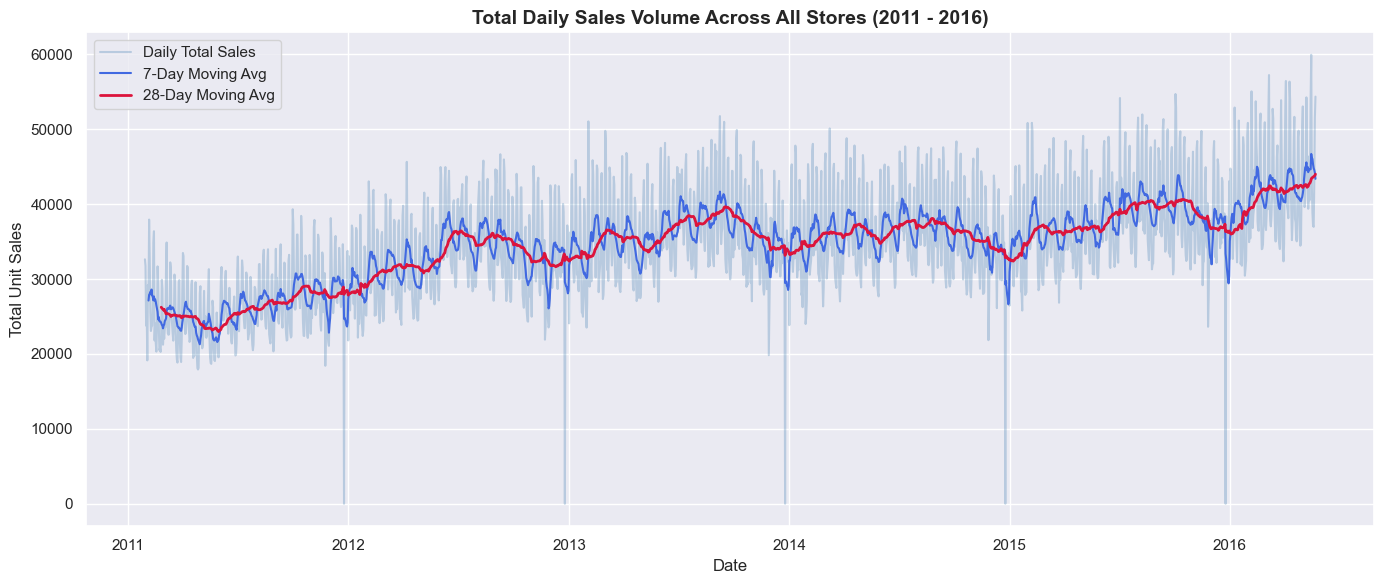

In [5]:
# Extract daily sales columns d_1, d_2, ..., d_n
d_cols = [c for c in sales_df.columns if c.startswith('d_')]

# Calculate total daily sales
daily_total_sales = sales_df[d_cols].sum(axis=0).reset_index()
daily_total_sales.columns = ['d', 'total_units_sold']

# Merge with calendar date information
daily_sales_dated = daily_total_sales.merge(calendar_df[['d', 'date', 'wm_yr_wk', 'event_name_1']], on='d', how='left')
daily_sales_dated['date'] = pd.to_datetime(daily_sales_dated['date'])
daily_sales_dated.set_index('date', inplace=True)

# Calculate rolling averages
daily_sales_dated['rolling_7d'] = daily_sales_dated['total_units_sold'].rolling(7).mean()
daily_sales_dated['rolling_28d'] = daily_sales_dated['total_units_sold'].rolling(28).mean()

# Plot Aggregate Demand Trend
plt.figure(figsize=(14, 6))
plt.plot(daily_sales_dated.index, daily_sales_dated['total_units_sold'], alpha=0.3, color='steelblue', label='Daily Total Sales')
plt.plot(daily_sales_dated.index, daily_sales_dated['rolling_7d'], color='royalblue', linewidth=1.5, label='7-Day Moving Avg')
plt.plot(daily_sales_dated.index, daily_sales_dated['rolling_28d'], color='crimson', linewidth=2, label='28-Day Moving Avg')

plt.title('Total Daily Sales Volume Across All Stores (2011 - 2016)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Unit Sales')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 4. Hierarchical Sales Breakdown (State, Store, Category)
Analysing how sales are partitioned across geographical regions (States) and product categories (`FOODS`, `HOBBIES`, `HOUSEHOLD`).

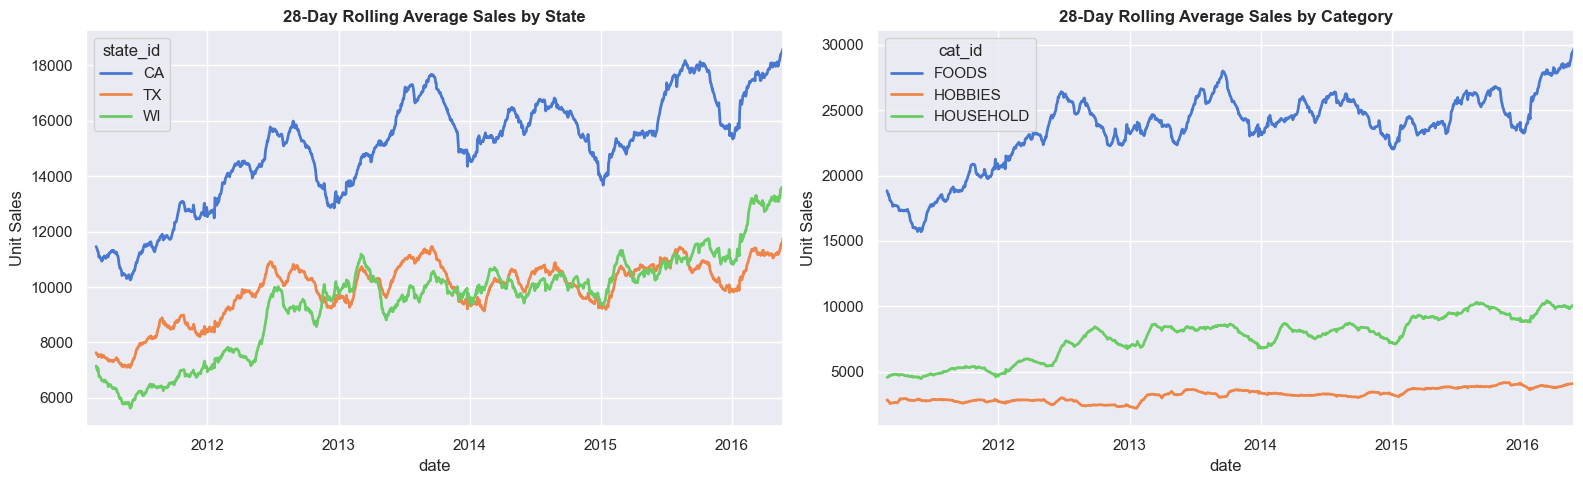

In [6]:
# Sales by State
state_sales = sales_df.groupby('state_id', observed=False)[d_cols].sum().T
state_sales.index = daily_sales_dated.index

# Sales by Category
cat_sales = sales_df.groupby('cat_id', observed=False)[d_cols].sum().T
cat_sales.index = daily_sales_dated.index

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot State Sales (28-day rolling average)
state_sales.rolling(28).mean().plot(ax=axes[0], linewidth=2)
axes[0].set_title('28-Day Rolling Average Sales by State', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Unit Sales')

# Plot Category Sales (28-day rolling average)
cat_sales.rolling(28).mean().plot(ax=axes[1], linewidth=2)
axes[1].set_title('28-Day Rolling Average Sales by Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Unit Sales')

plt.tight_layout()
plt.show()

## 5. Demand Intermittency & Syntetos-Boylan Categorization
In inventory optimization, demand is categorized based on two key metrics:
1. **Average Demand Interval (ADI)**: The average interval (in days) between successive demand occurrences.
2. **Coefficient of Variation Squared ($CV^2$)**: Quantifies demand size variability.

Categorization threshold rules:
- **Smooth**: ADI < 1.32 & $CV^2$ < 0.49
- **Erratic**: ADI < 1.32 & $CV^2$ >= 0.49
- **Intermittent**: ADI >= 1.32 & $CV^2$ < 0.49
- **Lumpy**: ADI >= 1.32 & $CV^2$ >= 0.49

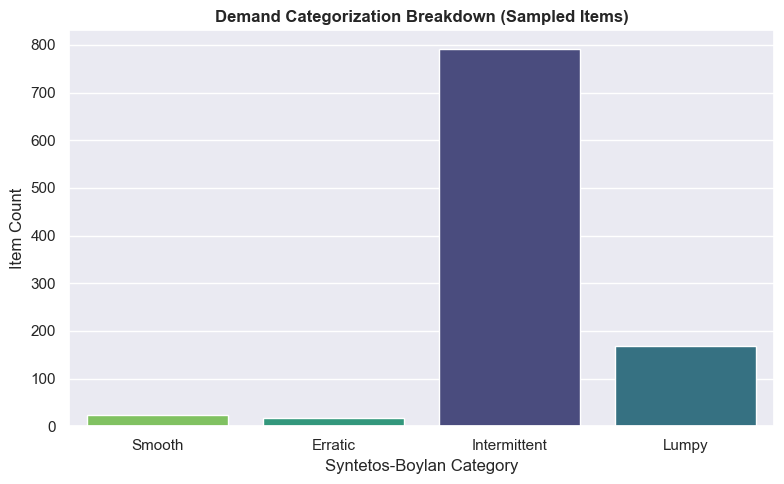

Demand Classification Breakdown:
Demand_Type
Intermittent    79.1
Lumpy           16.9
Smooth           2.3
Erratic          1.7
Name: proportion, dtype: float64


In [7]:
# Sample a subset of items to evaluate intermittency metrics
sample_items = sales_df.sample(n=1000, random_state=42)[d_cols].values

def calculate_intermittency_metrics(series):
    non_zero = series[series > 0]
    if len(non_zero) == 0:
        return np.nan, np.nan
    
    # ADI: Total periods / Number of non-zero periods
    adi = len(series) / len(non_zero)
    
    # CV^2: (Standard Deviation of non-zero demand / Mean of non-zero demand)^2
    cv2 = (np.std(non_zero) / np.mean(non_zero)) ** 2
    return adi, cv2

results = [calculate_intermittency_metrics(row) for row in sample_items]
metrics_df = pd.DataFrame(results, columns=['ADI', 'CV2']).dropna()

def classify_demand(row):
    if row['ADI'] < 1.32 and row['CV2'] < 0.49:
        return 'Smooth'
    elif row['ADI'] < 1.32 and row['CV2'] >= 0.49:
        return 'Erratic'
    elif row['ADI'] >= 1.32 and row['CV2'] < 0.49:
        return 'Intermittent'
    else:
        return 'Lumpy'

metrics_df['Demand_Type'] = metrics_df.apply(classify_demand, axis=1)

# Distribution plot
plt.figure(figsize=(8, 5))
sns.countplot(data=metrics_df, x='Demand_Type', hue='Demand_Type', order=['Smooth', 'Erratic', 'Intermittent', 'Lumpy'], palette='viridis', legend=False)
plt.title('Demand Categorization Breakdown (Sampled Items)', fontsize=12, fontweight='bold')
plt.xlabel('Syntetos-Boylan Category')
plt.ylabel('Item Count')
plt.tight_layout()
plt.show()

print("Demand Classification Breakdown:")
print(metrics_df['Demand_Type'].value_counts(normalize=True) * 100)

## 6. Price Volatility & Discount Dynamics
Analyzing historical price variances across stores and product categories.

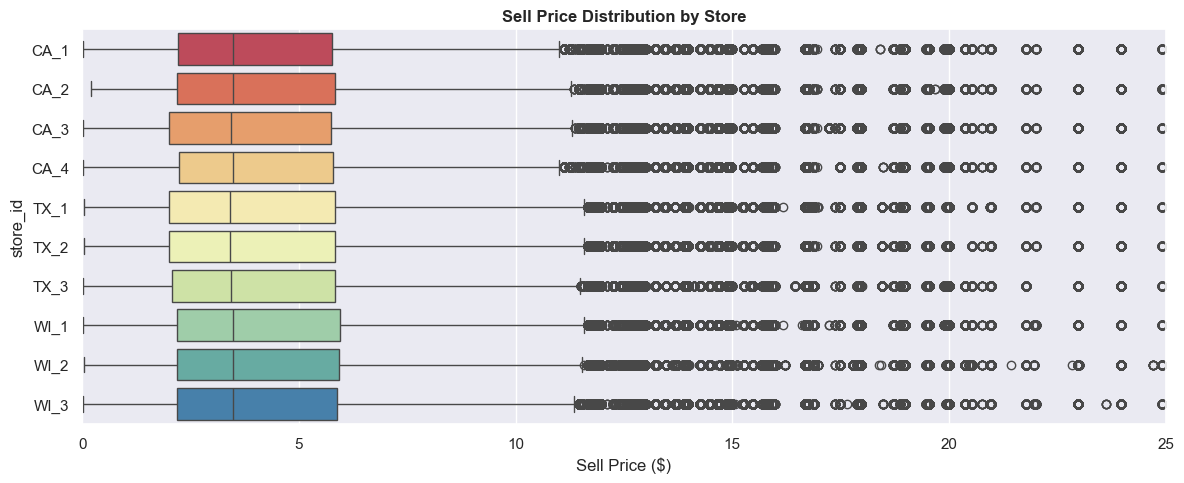

In [8]:
# Calculate item price stats
price_stats = sell_prices_df.groupby(['store_id', 'item_id'], observed=False)['sell_price'].agg(['min', 'max', 'mean', 'std']).reset_index()
price_stats['price_range'] = price_stats['max'] - price_stats['min']
price_stats['price_change_ratio'] = price_stats['price_range'] / (price_stats['min'] + 1e-5)

plt.figure(figsize=(12, 5))
sns.boxplot(data=sell_prices_df, x='sell_price', y='store_id', hue='store_id', palette='Spectral', legend=False)
plt.title('Sell Price Distribution by Store', fontsize=12, fontweight='bold')
plt.xlabel('Sell Price ($)')
plt.xlim(0, 25)
plt.tight_layout()
plt.show()

## 7. Calendar Events & SNAP Program Impact
Evaluating the lift effect on sales during SNAP days (Supplemental Nutrition Assistance Program) per state.

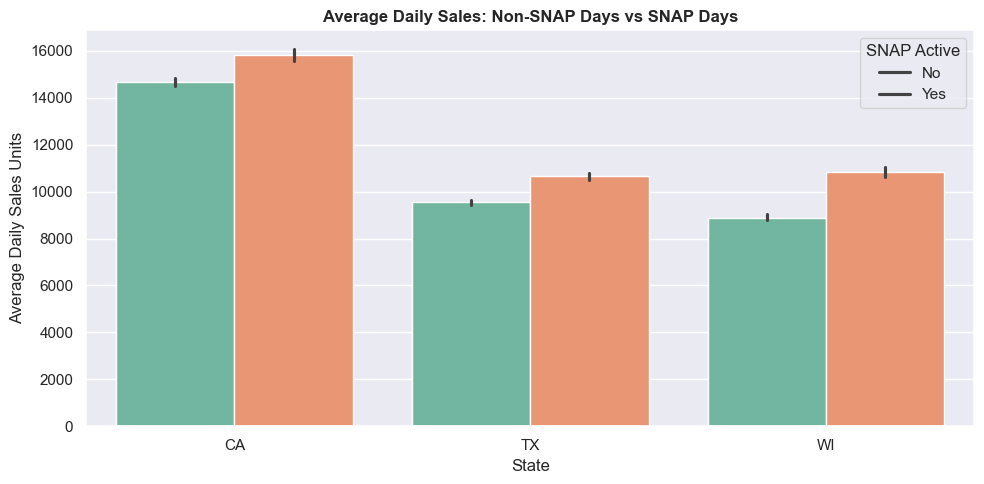

In [9]:
# Merge daily state sales with SNAP indicators
snap_analysis = []
for state in ['CA', 'TX', 'WI']:
    state_daily = sales_df[sales_df['state_id'] == state][d_cols].sum().reset_index()
    state_daily.columns = ['d', 'sales']
    merged = state_daily.merge(calendar_df[['d', f'snap_{state}']], on='d')
    merged['state'] = state
    merged.rename(columns={f'snap_{state}': 'snap_flag'}, inplace=True)
    snap_analysis.append(merged)

snap_df = pd.concat(snap_analysis, ignore_index=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=snap_df, x='state', y='sales', hue='snap_flag', palette='Set2')
plt.title('Average Daily Sales: Non-SNAP Days vs SNAP Days', fontsize=12, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Average Daily Sales Units')
plt.legend(title='SNAP Active', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

## 8. Summary of Key Insights & Next Steps

### Key EDA Findings:
1. **Strong Seasonality & Annual Dips**: Zero sales recorded consistently on Christmas Day across all stores.
2. **Category Dominance**: `FOODS` drives the largest unit volume and exhibits strong sensitivity to SNAP calendar days.
3. **High Intermittency**: A significant portion of SKUs exhibit intermittent or lumpy demand, requiring specialised forecasting techniques (e.g. LightGBM with Tweedie loss, Croston's method, or zero-inflated models).
4. **Price Volatility**: Periodic price promotions and price change ratios impact weekly demand volumes.

### Next Steps:
- **Module 2 (`02_feature_engineering.py` / notebook)**:
  - Construct lag features (7, 14, 28, 56 days).
  - Calculate rolling statistics (mean, std, min, max across 7, 14, 28, 60 days).
  - Encode calendar event types and SNAP flags per state.
  - Normalize price discount features (`sell_price` / `max_sell_price`).
- **Module 3 (Inventory Optimization)**:
  - Compute Reorder Points $ROP = (d_{avg} \times L) + SS$.
  - Calculate Safety Stock $SS = Z \times \sigma_{d} \times \sqrt{L}$ based on service level targets.